# Part 3: Can We Rescue v-Prediction?

Same setup as Part 2 but restricted to `swiss_roll`. We compare the unmodified flow-matching baseline against an **optimized** variant (`opt=True`) that injects low-rank noise aligned with the data's intrinsic 2D structure (via the random projection matrix `P`).

In [1]:
from src.model import JiM
from src.train import train_n_steps
from src.denoiser import Denoiser
from src.dataloader import get_dataloader

import torch
import torch.optim as optim

import matplotlib.pyplot as plt
from pathlib import Path
import numpy as np

In [2]:
DATASET = "swiss_roll"
DIMS = (2, 8, 32)
PRED_LOSS = (("x", "x"), ("x", "v"), ("v", "x"), ("v", "v"))

MODEL_DIR = Path("models")            # baseline (reuse weights trained in Part 2)
OPT_DIR   = Path("models/opt001")     # optimized run #001 (low-rank noise)
FIG_DIR   = Path("res/part3")
for d in (MODEL_DIR, OPT_DIR, FIG_DIR):
    d.mkdir(parents=True, exist_ok=True)

TRAIN_STEPS = 25000
STEPS = 50
BATCH = 1024
N_GEN = 2048

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

### Helpers

In [3]:
def model_tag(dataset, D, pred, loss):
    return f"{dataset}_D{D}_{pred}pred_{loss}loss"


def train_one_config(dataset, D, pred, loss, device, model_dir, opt, n_steps=TRAIN_STEPS):
    dataloader = get_dataloader(name=dataset, dim=D, batch_size=BATCH)
    model = JiM(hidden_dim=256, D=D).to(device)
    optimizer = optim.Adam(model.parameters(), lr=1e-3)
    train_n_steps(model, dataloader, optimizer, device, n_steps, pred, loss, opt=opt)
    torch.save(model.state_dict(), model_dir / f"{model_tag(dataset, D, pred, loss)}.pt")
    return model


def generate_samples(model, D, pred_type, device, opt=False, P=None, n=N_GEN):
    denoiser = Denoiser(model, steps=STEPS, D=D)
    return denoiser.generate(n, pred_type, device, P=P, opt=opt).cpu().numpy()


def get_ground_truth(dataset, D, n=N_GEN):
    loader = get_dataloader(name=dataset, dim=D, batch_size=n)
    return next(iter(loader))[:n].cpu().numpy()


def project_to_2d(samples, dataset, D):
    if D == 2:
        return samples
    loader = get_dataloader(name=dataset, dim=D, batch_size=1)
    return loader.dataset.to_2d(torch.from_numpy(samples)).numpy()


def sliced_wasserstein(x, y, n_proj=64, seed=0):
    """Sliced Wasserstein-1 distance between two point clouds. Lower = closer."""
    rng = np.random.default_rng(seed)
    n = min(len(x), len(y))
    x, y = x[:n], y[:n]
    dirs = rng.normal(size=(n_proj, x.shape[1])).astype(np.float64)
    dirs /= np.linalg.norm(dirs, axis=1, keepdims=True)
    px = np.sort(x @ dirs.T, axis=0)
    py = np.sort(y @ dirs.T, axis=0)
    return float(np.mean(np.abs(px - py)))


def plot_grid(dataset, device, model_dir, opt, title_suffix, save_name):
    """4 rows (pred/loss combos) x 3 cols (D in {2,8,32}). Loads weights from `model_dir`."""
    fig, axes = plt.subplots(
        len(PRED_LOSS), len(DIMS),
        figsize=(4 * len(DIMS), 4 * len(PRED_LOSS)),
        squeeze=False,
    )

    swds = {}
    for row, (pred, loss) in enumerate(PRED_LOSS):
        for col, D in enumerate(DIMS):
            ax = axes[row, col]
            tag = model_tag(dataset, D, pred, loss)

            model = JiM(hidden_dim=256, D=D).to(device)
            model.load_state_dict(torch.load(model_dir / f"{tag}.pt", map_location=device))
            model.eval()

            P = get_dataloader(name=dataset, dim=D, batch_size=1).dataset.P
            gen = generate_samples(model, D, pred, device, opt=opt, P=P)
            gt = get_ground_truth(dataset, D)

            gen2d = project_to_2d(gen, dataset, D)
            gt2d = project_to_2d(gt, dataset, D)

            swd = sliced_wasserstein(gen2d, gt2d)
            swds[(pred, loss, D)] = swd

            ax.scatter(gt2d[:, 0],  gt2d[:, 1],  s=3, alpha=0.25, c="gray", label="ground truth")
            ax.scatter(gen2d[:, 0], gen2d[:, 1], s=3, alpha=0.55, c="C0",   label="generated")
            ax.set_title(f"{pred}-pred + {loss}-loss   D={D}", fontsize=11)
            ax.set_aspect("equal")
            ax.set_xticks([]); ax.set_yticks([])
            ax.text(0.02, 0.98, f"SWD = {swd:.3f}", transform=ax.transAxes,
                    ha="left", va="top", fontsize=9,
                    bbox=dict(boxstyle="round,pad=0.3", facecolor="white",
                              edgecolor="none", alpha=0.8))

    handles, labels = axes[0, 0].get_legend_handles_labels()
    fig.legend(handles, labels, loc="upper center", ncol=2, frameon=False,
               bbox_to_anchor=(0.5, 1.02), fontsize=11)
    fig.suptitle(f"Dataset: {dataset} - {title_suffix}", fontsize=14, y=1.05)
    fig.tight_layout()
    fig.savefig(FIG_DIR / save_name, dpi=150, bbox_inches="tight")
    plt.show()
    return swds

## Baseline

Reuses the weights trained in Part 2 (`models/swiss_roll_*.pt`). v-pred + v-loss collapses sharply as ambient `D` grows - the failure mode this part aims to rescue.

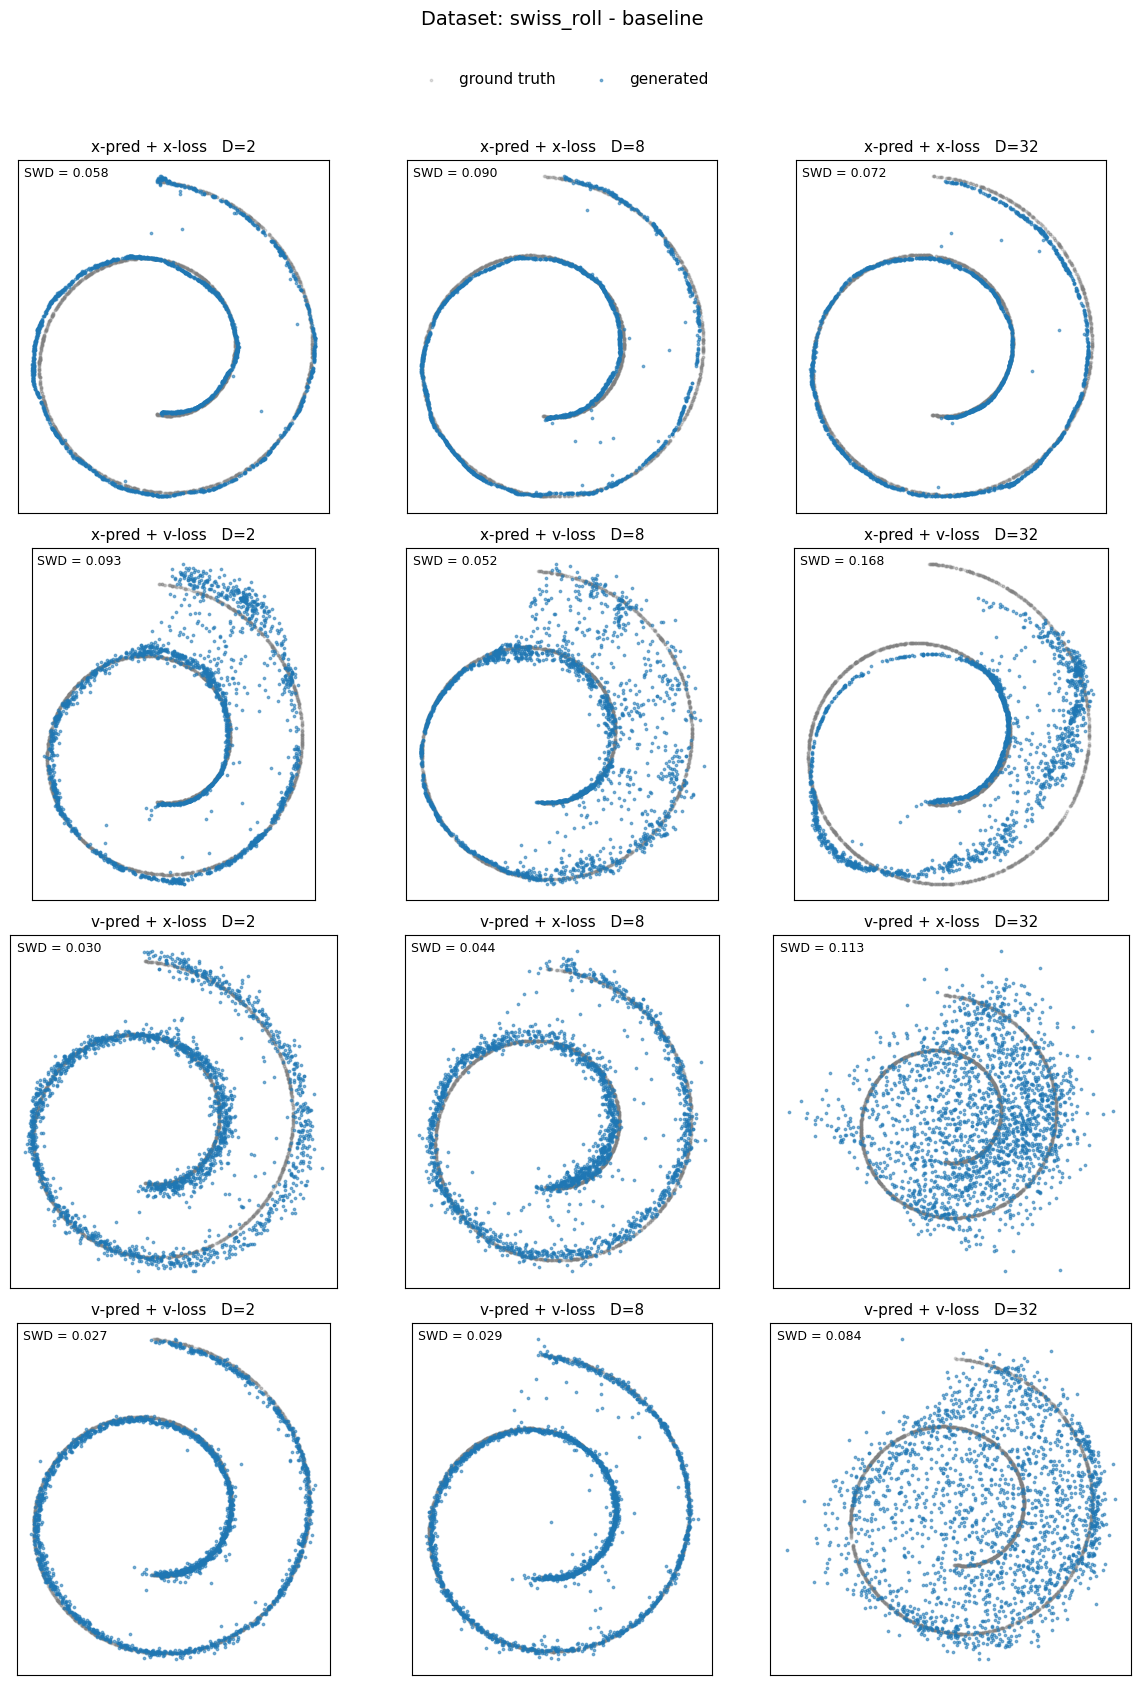

In [4]:
swds_baseline = plot_grid(
    DATASET, device,
    model_dir=MODEL_DIR, opt=False,
    title_suffix="baseline",
    save_name=f"{DATASET}_grid_baseline.png",
)

## Improved (`opt001`)

`opt=True` draws training noise and the initial sampling latent in the intrinsic 2D subspace and lifts them through `P`, so $z_t$ stays on the same low-rank manifold the data lives on. Trains all 12 configs on `swiss_roll` and saves to `models/opt001/`. Re-runs are cached - delete a checkpoint to retrain.

In [5]:
for D in DIMS:
    for pred, loss in PRED_LOSS:
        tag = model_tag(DATASET, D, pred, loss)
        path = OPT_DIR / f"{tag}.pt"
        if path.exists():
            print(f"[skip] {tag} already trained")
            continue
        print(f"[train] {tag}")
        train_one_config(DATASET, D, pred, loss, device, model_dir=OPT_DIR, opt=True)

[train] swiss_roll_D2_xpred_xloss
step    500/25000  loss 0.279017
step   1000/25000  loss 0.265010
step   1500/25000  loss 0.264479
step   2000/25000  loss 0.265493
step   2500/25000  loss 0.264652
step   3000/25000  loss 0.264548
step   3500/25000  loss 0.264411
step   4000/25000  loss 0.264573
step   4500/25000  loss 0.263977
step   5000/25000  loss 0.264591
step   5500/25000  loss 0.263358
step   6000/25000  loss 0.264066
step   6500/25000  loss 0.264247
step   7000/25000  loss 0.264012
step   7500/25000  loss 0.264030
step   8000/25000  loss 0.264090
step   8500/25000  loss 0.264832
step   9000/25000  loss 0.263793
step   9500/25000  loss 0.263981
step  10000/25000  loss 0.263425
step  10500/25000  loss 0.262985
step  11000/25000  loss 0.263550
step  11500/25000  loss 0.263505
step  12000/25000  loss 0.264191
step  12500/25000  loss 0.263088
step  13000/25000  loss 0.263791
step  13500/25000  loss 0.263558
step  14000/25000  loss 0.264292
step  14500/25000  loss 0.263335
step  150

In [ ]:
swds_opt = plot_grid(
    DATASET, device,
    model_dir=OPT_DIR, opt=True,
    title_suffix="opt001 (low-rank noise)",
    save_name=f"{DATASET}_grid_opt001.png",
)

In [ ]:
# Side-by-side SWD table: baseline vs opt001
print(f"{'config':<22}{'D':>4}  {'baseline':>10}  {'opt001':>10}  {'delta':>10}")
print("-" * 60)
for pred, loss in PRED_LOSS:
    for D in DIMS:
        b = swds_baseline[(pred, loss, D)]
        o = swds_opt[(pred, loss, D)]
        print(f"{pred}-pred + {loss}-loss   {D:>4}  {b:>10.4f}  {o:>10.4f}  {o - b:>+10.4f}")